# 实验一：中文文本分析与可视化——以“今日头条”汽车新闻为例

In [1]:
# 导入核心库
import pandas as pd
import jieba
import collections
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from PIL import Image
import numpy as np

# Matplotlib全局配置
plt.rcParams['font.family'] = 'SimHei' # 设置中文字体为黑体
plt.rcParams['axes.unicode_minus'] = False # 解决坐标轴负号显示问题
%matplotlib inline
%config InlineBackend.figure_format = "retina" # 提高图表清晰度

d:\anoconda\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
d:\anoconda\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [4]:
# 读取Excel文件
df = pd.read_excel("D:\自然语言处理(硕)\corpus_data\今日头条新闻数据\今日头条-汽车.xlsx")

# 显示前5行数据，确认数据已正确加载
print("数据预览：")
display(df.head())

# 查看数据基本信息
print("\n数据信息：")
df.info()

数据预览：


,标题,作者,评论数,时间,内容
0,经常这么过马路，轮胎大鼓包就不可避免了！,酷车无忧i ⋅,3评论 ⋅,2018-10-19 15:50:09,汽车用久了，很多地方都会磨损，尤其的轮胎，是最容易受到地面的摩擦，一摩擦，轮胎就会消耗。轮胎...
1,“禁止长时间停车”具体是三分钟还是五分钟？蜀黍说：都不是！,岱山检察 ⋅,117评论 ⋅,NaN,在很多道路旁都有设置“禁止停车”和“禁止长时间停车”的标志，“禁止长时间停车”中的“长时间”...
2,90后必选的15万落地四款小钢炮 你值得拥有！,老徐评车 ⋅,11评论 ⋅,NaN,推荐车型1：奥迪A3官方售价：19.05-25.62万元（部分地区优惠4.8万元）奥迪在国内...
3,扶不起的七折豹，无人问津，我都哭了你们都不买我,车侃家 ⋅,93评论 ⋅,NaN,一看标题，你们就知道我们今天要介绍的主角了：捷豹和路虎。这两个品牌本身是没有连在一起称呼的，...
4,测试\迈巴赫S 680：大哥还是大哥，凭什么比宝马760Li贵了40万？,大河车社 ⋅,160评论 ⋅,NaN,当涡轮增压不再局限于小排量发动机后，12缸引擎就逐渐从性能标签转化为精神的象征了。但是呢，对...



数据信息：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2092 entries, 0 to 2091
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   标题      2092 non-null   object
 1   作者      2092 non-null   object
 2   评论数     2092 non-null   object
 3   时间      667 non-null    object
 4   内容      2092 non-null   object
dtypes: object(5)
memory usage: 81.8+ KB


In [5]:
# 将'内容'列的所有文本合并成一个长字符串
text_corpus = " ".join(df["内容"].astype(str).tolist()) # 使用astype(str)确保所有内容都是字符串类型
print(f"语料库总字数：{len(text_corpus)}")

语料库总字数：2176408


In [6]:
# 使用jieba进行精确模式分词
words = jieba.lcut(text_corpus)
print(f"分词后的总词数：{len(words)}")
print("分词结果预览 (前20个词):", words[:20])

Building prefix dict from the default dictionary ...
Dumping model to file cache C:\Users\Dell\AppData\Local\Temp\jieba.cache
Loading model cost 0.763 seconds.
Prefix dict has been built successfully.


分词后的总词数：1291587
分词结果预览 (前20个词): ['汽车', '用久', '了', '，', '很多', '地方', '都', '会', '磨损', '，', '尤其', '的', '轮胎', '，', '是', '最', '容易', '受到', '地面', '的']


In [7]:
# 使用collections.Counter统计词频
word_counts = collections.Counter(words)

# 获取频率最高的30个词
top_30_words = word_counts.most_common(30)
print("词频最高的30个词：")
print(top_30_words)

词频最高的30个词：
[('，', 105689), ('的', 80436), ('。', 36094), (' ', 19345), ('是', 17930), ('了', 17095), ('在', 14197), ('也', 10806), ('、', 9544), ('和', 7285), ('都', 7153), ('有', 6861), ('就', 5912), ('车型', 5528), ('车', 5494), ('上', 5307), ('汽车', 4322), ('这', 4213), ('设计', 4173), ('不', 3943), ('很', 3883), ('可以', 3840), ('它', 3755), ('会', 3714), ('为', 3602), ('发动机', 3572), ('“', 3339), ('你', 3305), ('”', 3303), ('：', 3242)]


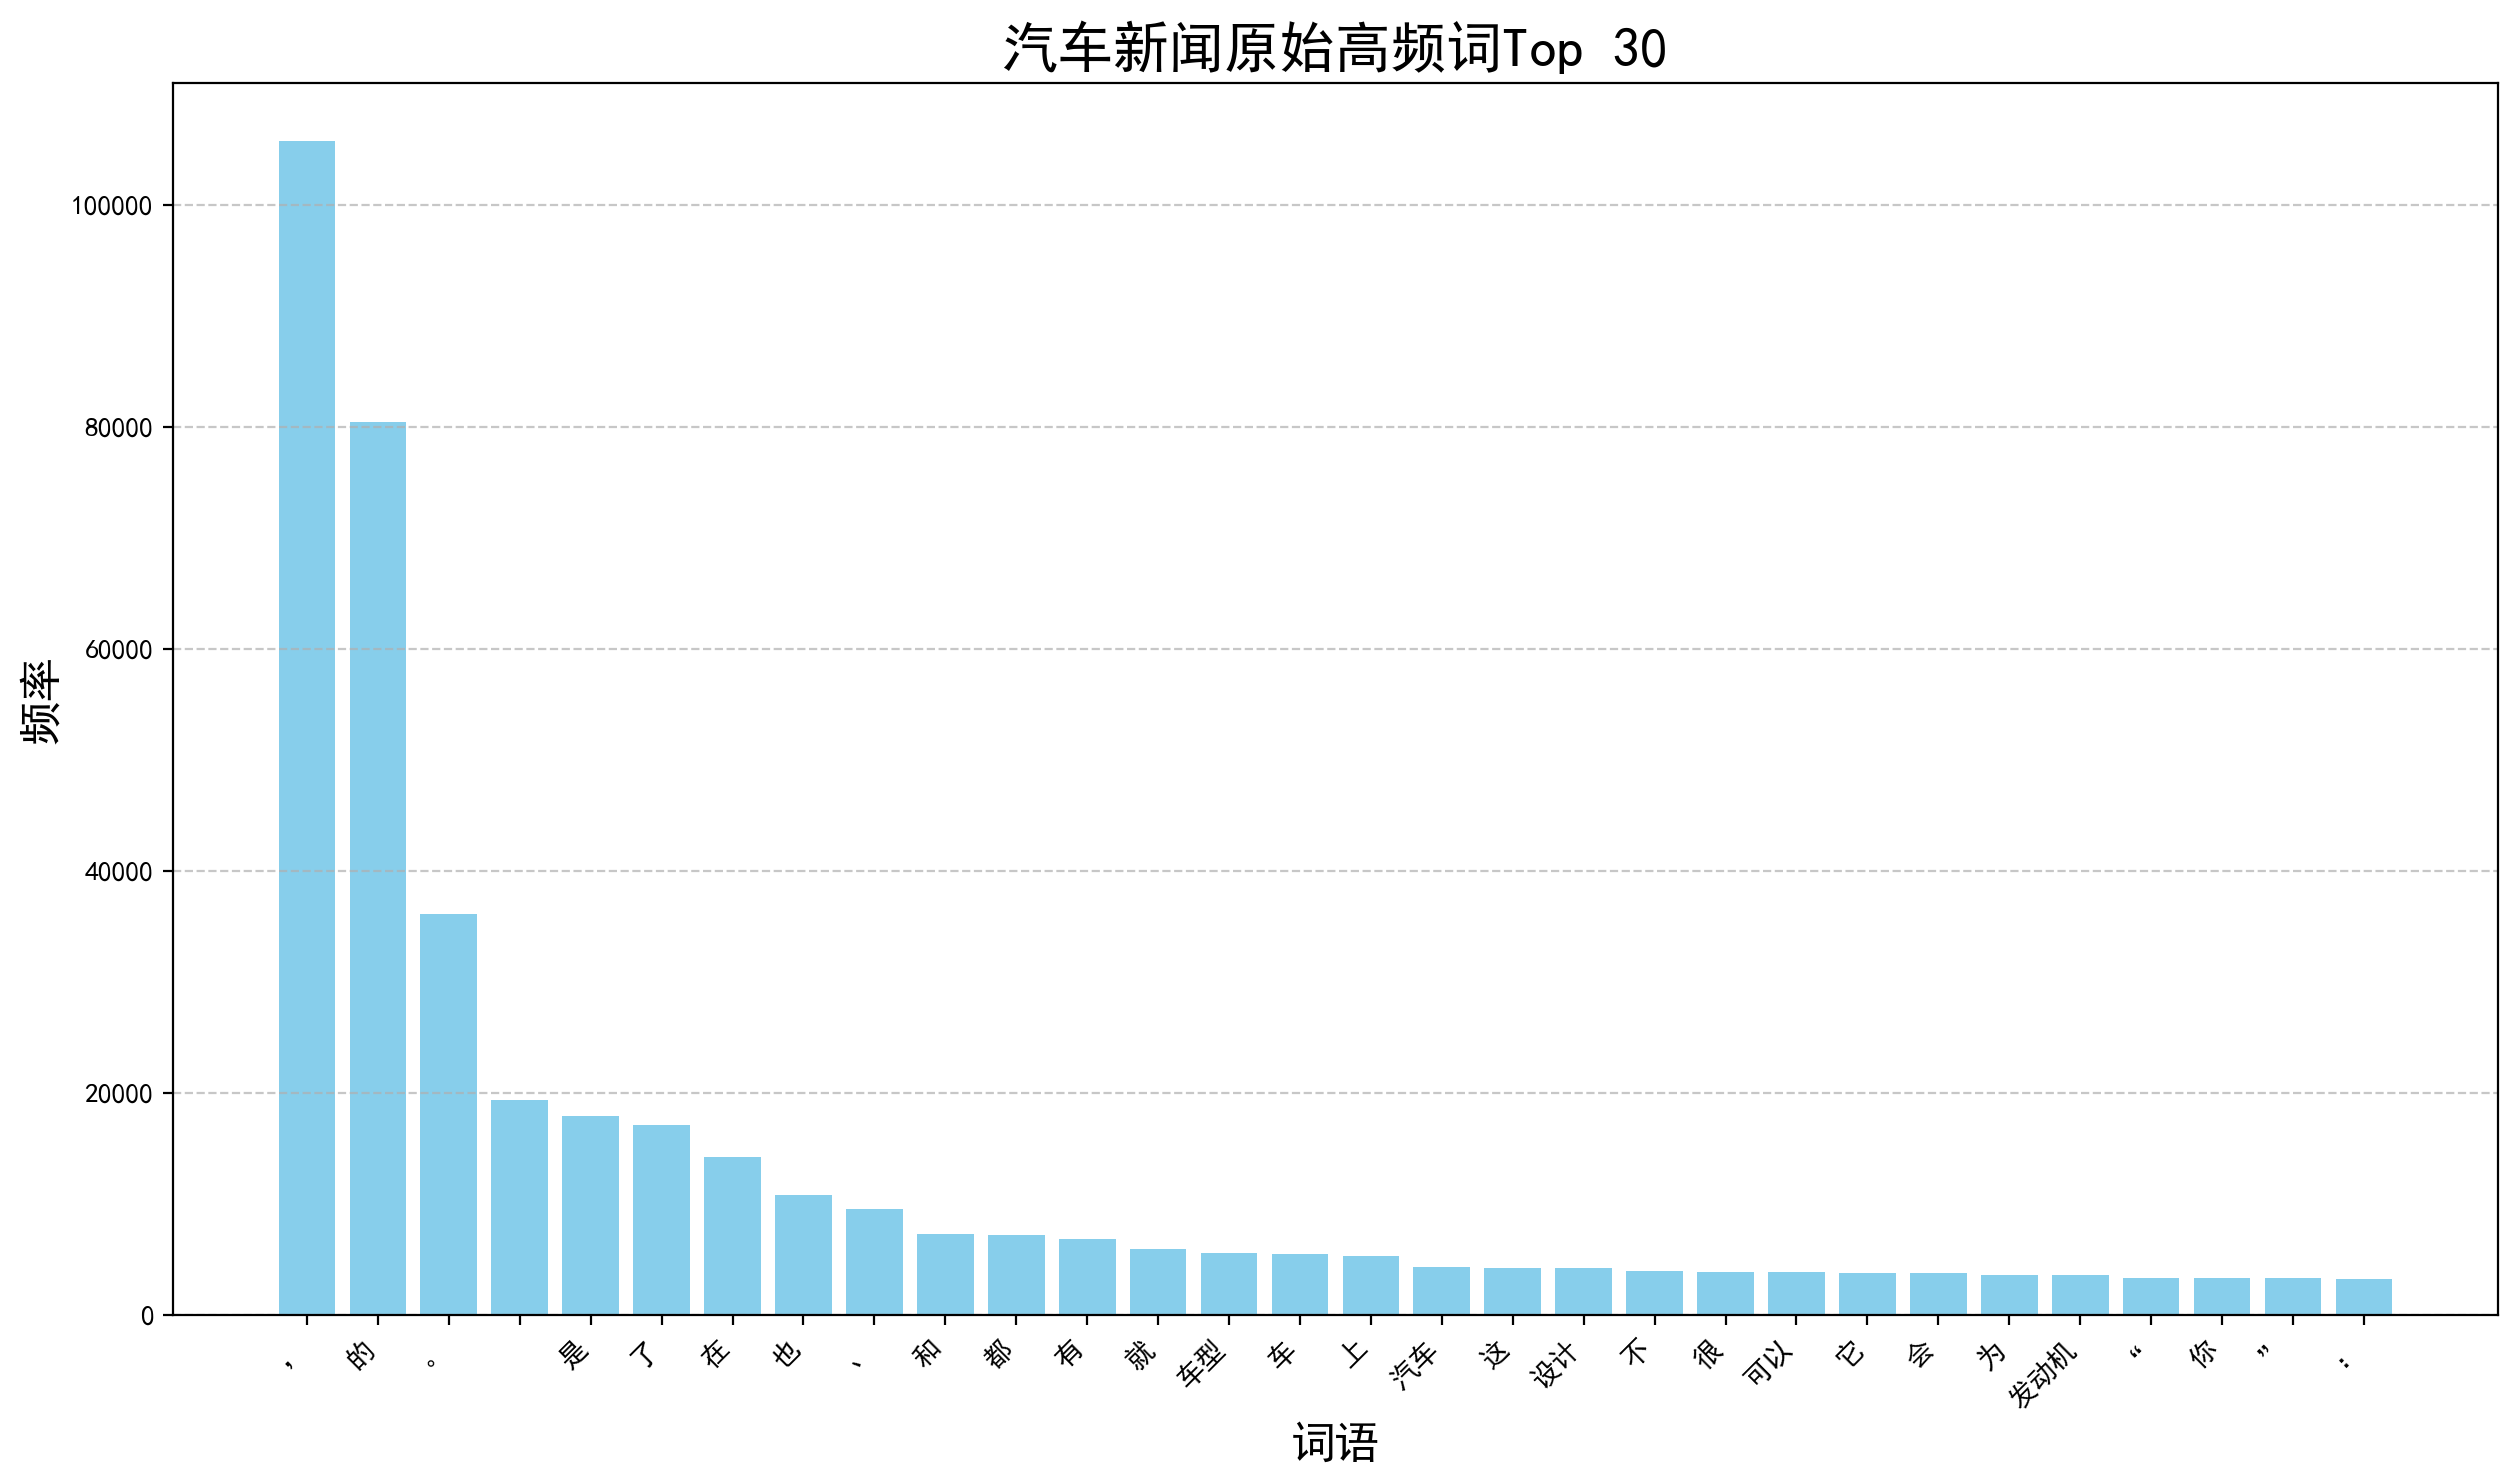

In [8]:
# 准备绘图数据
words, frequencies = zip(*top_30_words)

# 创建图表
plt.figure(figsize=(15, 8))
plt.bar(words, frequencies, color='skyblue')

# 添加图表元素
plt.title('汽车新闻原始高频词Top 30', fontsize=20)
plt.xlabel('词语', fontsize=16)
plt.ylabel('频率', fontsize=16)
plt.xticks(rotation=45, ha='right') # 旋转x轴标签以防重叠
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 显示图表
plt.show()

In [10]:
# 从文件加载停用词
with open('D:\自然语言处理(硕)\corpus_data\stopwords.txt', 'r', encoding='utf-8') as f:
    stopwords = {line.strip() for line in f}

# 添加一些可能在汽车领域特有的、但意义不大的词
stopwords.update(['车型', '新车', ' ', '\n', '汽车']) # ' '和'\n'是分词后可能产生的空白符

print(f"停用词库大小: {len(stopwords)}")

停用词库大小: 755


In [11]:
# 过滤停用词
filtered_words = [word for word in words if word not in stopwords and len(word) > 1] # 同时过滤掉单字词
print(f"去除停用词和单字词后的总词数: {len(filtered_words)}")

# 重新进行词频统计
filtered_word_counts = collections.Counter(filtered_words)
filtered_top_30 = filtered_word_counts.most_common(30)
print("\n去除停用词后的高频词Top 30:")
print(filtered_top_30)

去除停用词和单字词后的总词数: 2

去除停用词后的高频词Top 30:
[('设计', 1), ('发动机', 1)]


In [12]:
def generate_wordcloud(word_counts_dict, background_shape_path=None):
    """
    根据词频字典生成词云图。
    
    参数:
    word_counts_dict (dict): 词语为键，频率为值的字典。
    background_shape_path (str, optional): 蒙版图片的路径. 默认为None.
    """
    mask = None
    if background_shape_path:
        mask = np.array(Image.open(background_shape_path))

    wordcloud = WordCloud(
        font_path='C:/Windows/Fonts/msyh.ttc', # 请确保字体路径正确
        background_color="white",
        width=1000,
        height=600,
        mask=mask,
        contour_width=3, 
        contour_color='steelblue',
        collocations=False # 避免词语重复显示
    )
    
    wordcloud.generate_from_frequencies(word_counts_dict)
    
    plt.figure(figsize=(12, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.show()

--- 未去除停用词的词云图 ---


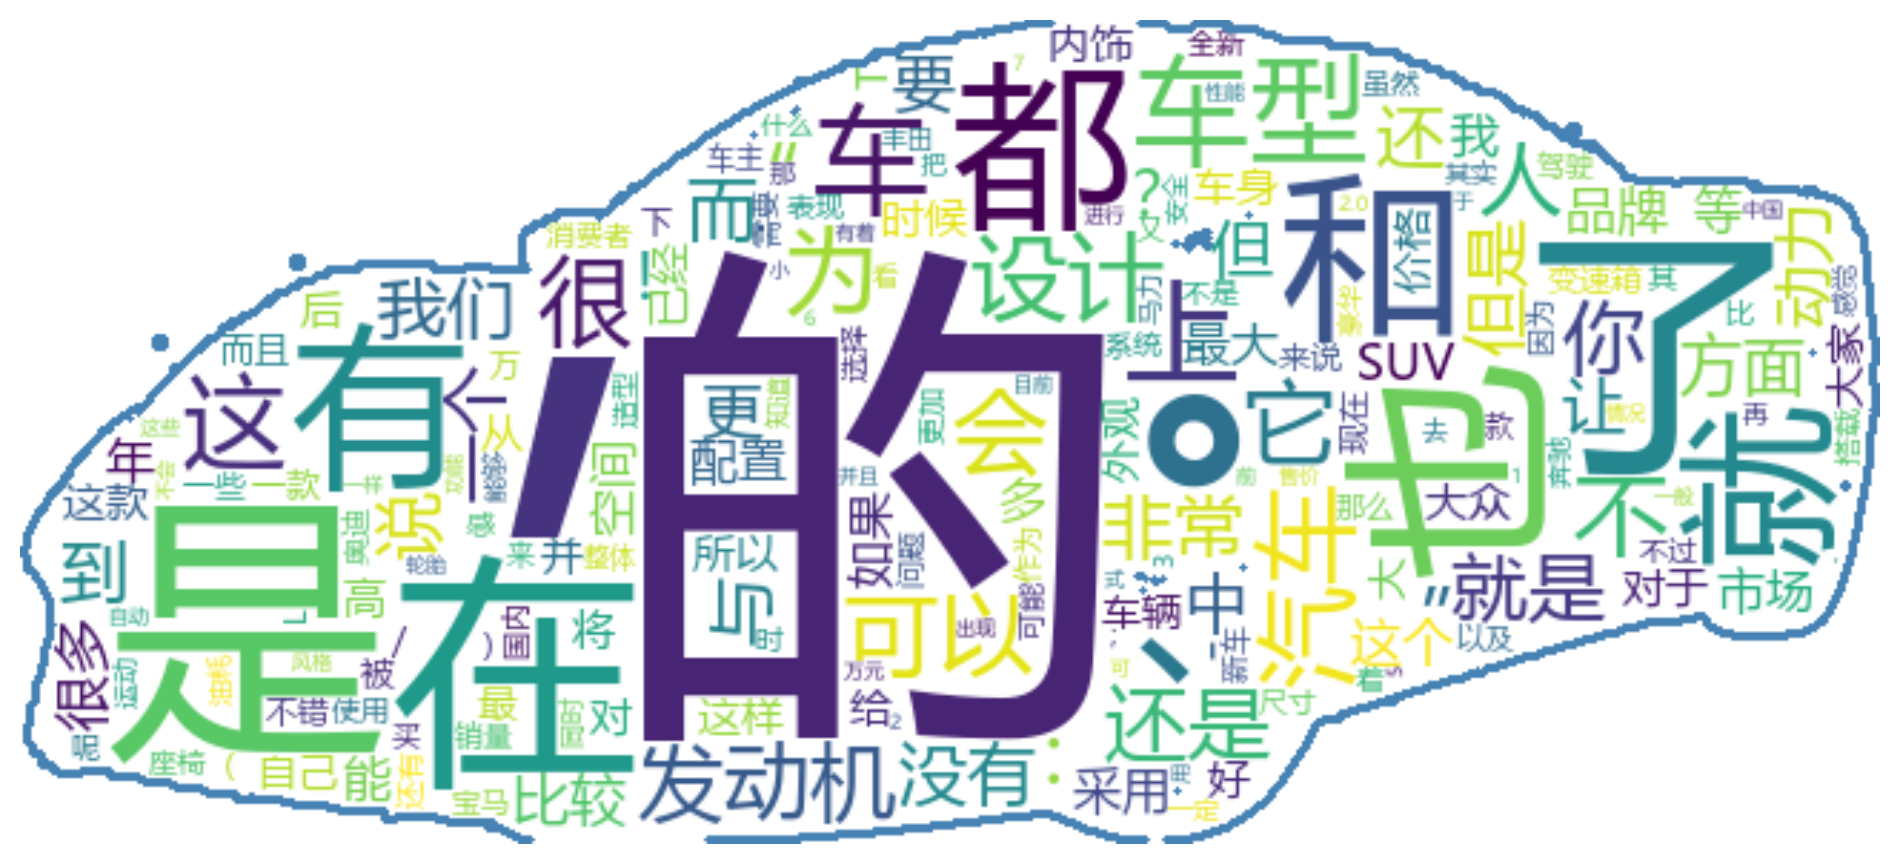


--- 去除停用词后的词云图 ---


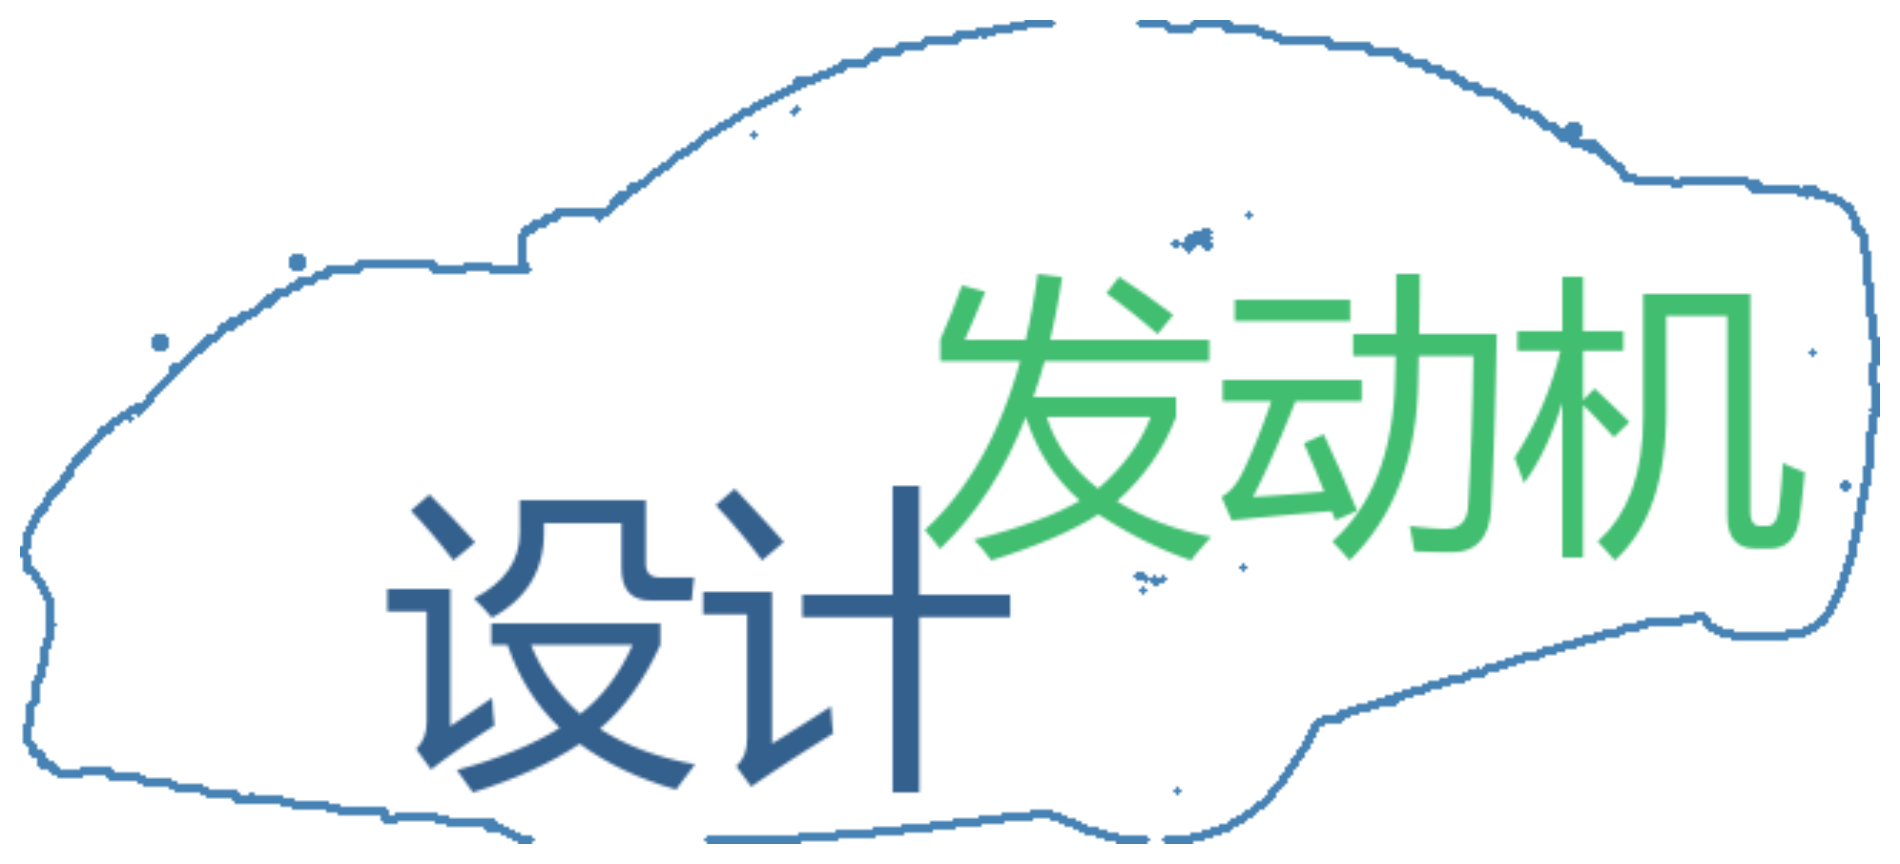

In [14]:
# 版本一：未去除停用词的词云图
print("--- 未去除停用词的词云图 ---")
generate_wordcloud(word_counts, background_shape_path="D:\自然语言处理(硕)\corpus_data\car.png")

# 版本二：去除停用词后的词云图
print("\n--- 去除停用词后的词云图 ---")
generate_wordcloud(filtered_word_counts, background_shape_path="D:\自然语言处理(硕)\corpus_data\car.png")